# Estudo dos Ratings — data_spliting_hybrid

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df = pd.read_csv("data_spliting_hybrid/testing.csv")

print(f"Total de registros: {len(df):,}")
print(f"Usuários únicos:    {df['userId'].nunique():,}")
print(f"Filmes únicos:      {df['movieId'].nunique():,}")

Total de registros: 31,531
Usuários únicos:    610
Filmes únicos:      6,107


## 1 — Notas médias

In [2]:
media_geral = df["rating"].mean()
mediana     = df["rating"].median()
desvio      = df["rating"].std()
minimo      = df["rating"].min()
maximo      = df["rating"].max()

print(f"Média geral:   {media_geral:.4f}")
print(f"Mediana:       {mediana:.4f}")
print(f"Desvio padrão: {desvio:.4f}")
print(f"Mínimo:        {minimo}")
print(f"Máximo:        {maximo}")

Média geral:   3.5023
Mediana:       3.5000
Desvio padrão: 1.0412
Mínimo:        0.5
Máximo:        5.0


## 2 — Distribuição de cada rating

        quantidade  percentual (%)
rating                            
0.5            455            1.44
1.0            873            2.77
1.5            519            1.65
2.0           2337            7.41
2.5           1688            5.35
3.0           6403           20.31
3.5           4027           12.77
4.0           8441           26.77
4.5           2699            8.56
5.0           4089           12.97


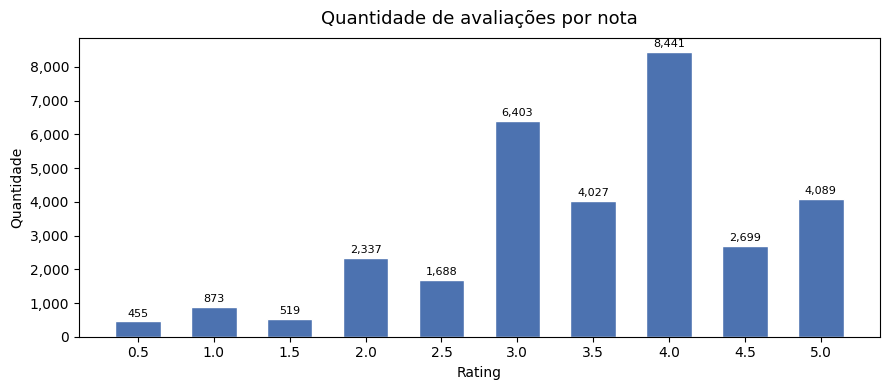

In [3]:
contagem = df["rating"].value_counts().sort_index()
pct      = (contagem / len(df) * 100).round(2)

dist = pd.DataFrame({"quantidade": contagem, "percentual (%)": pct})
print(dist.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(contagem.index.astype(str), contagem.values, width=0.6, color="#4C72B0", edgecolor="white")

for bar, val in zip(bars, contagem.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + contagem.max() * 0.01,
            f"{val:,}", ha="center", va="bottom", fontsize=8)

ax.set_title("Quantidade de avaliações por nota", fontsize=13, pad=10)
ax.set_xlabel("Rating")
ax.set_ylabel("Quantidade")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 3 — Usuários com mais e menos filmes avaliados

=== Estatísticas gerais de avaliações por usuário ===
count    610.00
mean      51.69
std       80.78
min        6.00
25%       12.00
50%       24.00
75%       53.00
max      811.00

--- Top 15 usuários com MAIS avaliações ---
 userId  total_avaliacoes
    414               811
    599               744
    474               634
    448               561
    274               405
    610               393
     68               379
    380               366
    606               338
    288               318
    249               316
    387               311
    182               294
    307               294
    298               285

--- Top 15 usuários com MENOS avaliações ---
 userId  total_avaliacoes
     53                 6
    442                 6
     49                 7
    147                 7
    157                 7
    320                 7
    324                 7
    576                 7
    127                 8
    138                 8
    189                 8

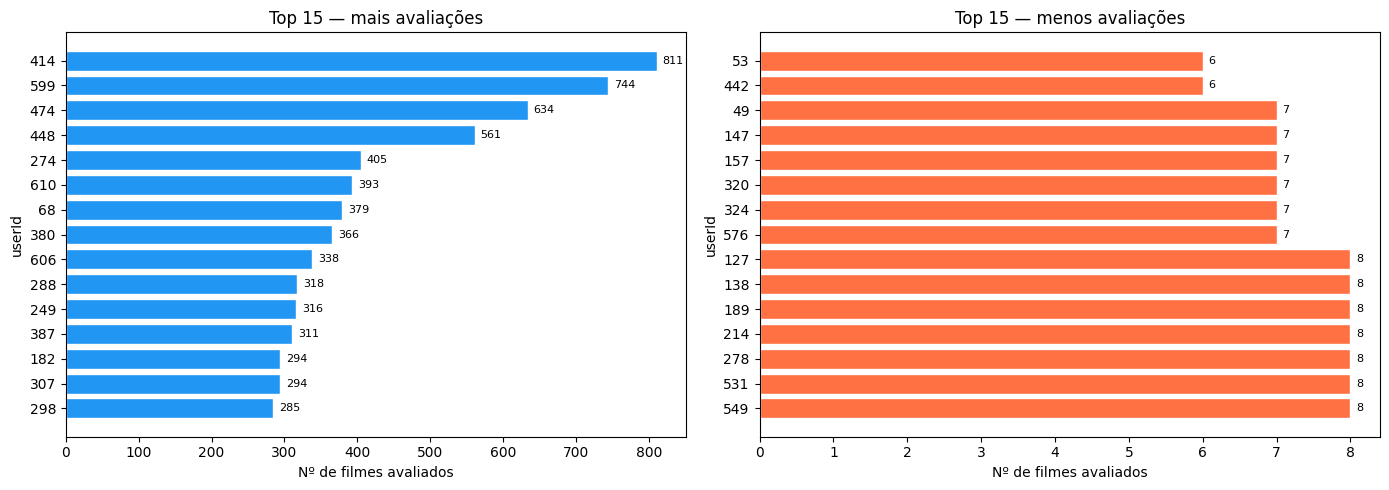

In [4]:
avaliacoes_por_usuario = df.groupby("userId")["movieId"].count().rename("total_avaliacoes")

print("=== Estatísticas gerais de avaliações por usuário ===")
print(avaliacoes_por_usuario.describe().round(2).to_string())

TOP_N = 15

top_mais = avaliacoes_por_usuario.nlargest(TOP_N).reset_index()
top_menos = avaliacoes_por_usuario.nsmallest(TOP_N).reset_index()

print(f"\n--- Top {TOP_N} usuários com MAIS avaliações ---")
print(top_mais.to_string(index=False))

print(f"\n--- Top {TOP_N} usuários com MENOS avaliações ---")
print(top_menos.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, titulo, cor in [
    (axes[0], top_mais,  f"Top {TOP_N} — mais avaliações",  "#2196F3"),
    (axes[1], top_menos, f"Top {TOP_N} — menos avaliações", "#FF7043"),
]:
    bars = ax.barh(data["userId"].astype(str), data["total_avaliacoes"], color=cor, edgecolor="white")
    ax.invert_yaxis()
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel("Nº de filmes avaliados")
    ax.set_ylabel("userId")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar, val in zip(bars, data["total_avaliacoes"]):
        ax.text(bar.get_width() + max(data["total_avaliacoes"]) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 4 — Filmes com nota ≥ 4.0 por usuário

Usuários com pelo menos 1 filme nota >= 4.0: 609 / 610 (99.8%)

Estatísticas de filmes nota >= 4.0 por usuário:
count    609.00
mean      25.01
std       32.81
min        1.00
25%        7.00
50%       12.00
75%       29.00
max      369.00

--- Top 15 usuários com mais filmes nota >= 4.0 ---
 userId  filmes_nota_alta
    414               369
    474               237
    380               201
    606               186
    610               186
    603               171
    105               168
    249               154
    182               147
    448               138
    318               135
    305               126
    477               115
    483               114
    177               107


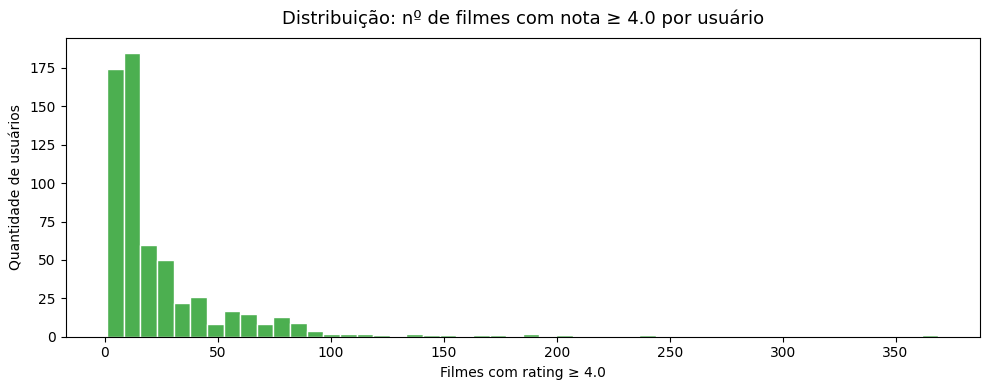

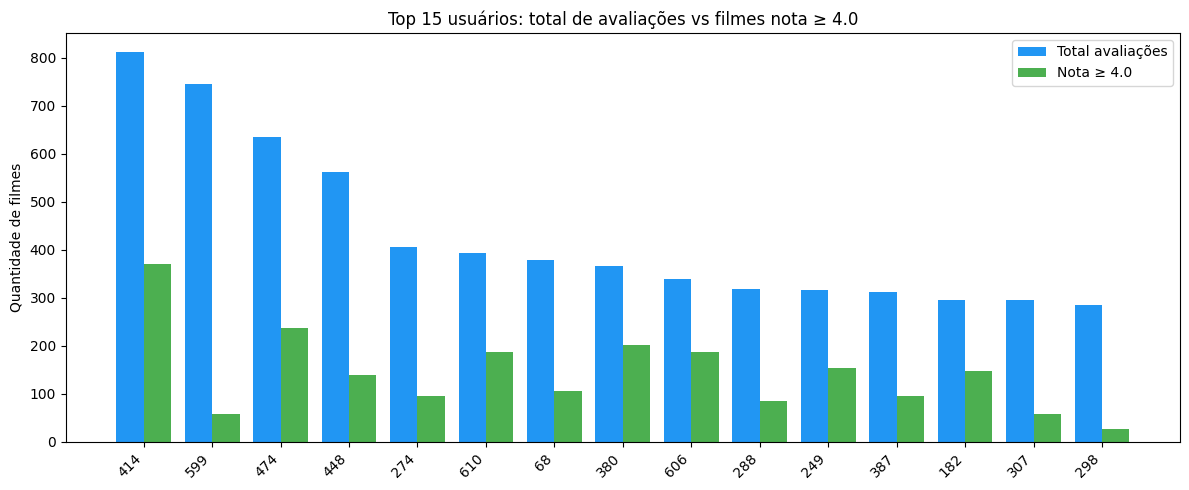


--- Percentual de filmes nota alta sobre total (top 15 usuários mais ativos) ---
 userId  total_avaliacoes  filmes_nota_alta  pct_nota_alta
    414               811               369           45.5
    599               744                57            7.7
    474               634               237           37.4
    448               561               138           24.6
    274               405                96           23.7
    610               393               186           47.3
     68               379               106           28.0
    380               366               201           54.9
    606               338               186           55.0
    288               318                84           26.4
    249               316               154           48.7
    387               311                95           30.5
    182               294               147           50.0
    307               294                57           19.4
    298               285        

In [5]:
THRESHOLD = 4.0

filmes_altos = (
    df[df["rating"] >= THRESHOLD]
    .groupby("userId")["movieId"]
    .count()
    .rename("filmes_nota_alta")
    .reset_index()
)

total_usuarios = df["userId"].nunique()
usuarios_com_alta = len(filmes_altos)
print(f"Usuários com pelo menos 1 filme nota >= {THRESHOLD}: {usuarios_com_alta:,} / {total_usuarios:,} ({usuarios_com_alta/total_usuarios*100:.1f}%)")
print(f"\nEstatísticas de filmes nota >= {THRESHOLD} por usuário:")
print(filmes_altos["filmes_nota_alta"].describe().round(2).to_string())

# Top e bottom por filmes de nota alta
top_altos  = filmes_altos.nlargest(TOP_N, "filmes_nota_alta")
top_baixos = filmes_altos.nsmallest(TOP_N, "filmes_nota_alta")

print(f"\n--- Top {TOP_N} usuários com mais filmes nota >= {THRESHOLD} ---")
print(top_altos.to_string(index=False))

# Histograma da distribuição
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(filmes_altos["filmes_nota_alta"], bins=50, color="#4CAF50", edgecolor="white")
ax.set_title(f"Distribuição: nº de filmes com nota ≥ {THRESHOLD} por usuário", fontsize=13, pad=10)
ax.set_xlabel(f"Filmes com rating ≥ {THRESHOLD}")
ax.set_ylabel("Quantidade de usuários")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

# Comparação: total de avaliações vs filmes nota alta (top 15)
merged = (
    avaliacoes_por_usuario.reset_index()
    .merge(filmes_altos, on="userId")
    .nlargest(TOP_N, "total_avaliacoes")
)
merged["pct_nota_alta"] = (merged["filmes_nota_alta"] / merged["total_avaliacoes"] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(merged))
width = 0.4
ax.bar([i - width/2 for i in x], merged["total_avaliacoes"], width=width, label="Total avaliações", color="#2196F3")
ax.bar([i + width/2 for i in x], merged["filmes_nota_alta"],  width=width, label=f"Nota ≥ {THRESHOLD}",        color="#4CAF50")
ax.set_xticks(list(x))
ax.set_xticklabels(merged["userId"].astype(str), rotation=45, ha="right")
ax.set_title(f"Top {TOP_N} usuários: total de avaliações vs filmes nota ≥ {THRESHOLD}", fontsize=12)
ax.set_ylabel("Quantidade de filmes")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
plt.tight_layout()
plt.show()

print("\n--- Percentual de filmes nota alta sobre total (top 15 usuários mais ativos) ---")
print(merged[["userId", "total_avaliacoes", "filmes_nota_alta", "pct_nota_alta"]].to_string(index=False))

## 5 — Usuários com menos de 10 filmes avaliados com nota ≥ 4.0

In [6]:
LIMITE = 10

# Usuários que têm pelo menos 1 avaliação >= 4.0, mas menos de LIMITE
poucos_altos = filmes_altos[filmes_altos["filmes_nota_alta"] < LIMITE].sort_values("filmes_nota_alta")

# Usuários que não têm NENHUMA avaliação >= 4.0
sem_nota_alta = (
    avaliacoes_por_usuario.reset_index()[
        ~avaliacoes_por_usuario.reset_index()["userId"].isin(filmes_altos["userId"])
    ][["userId"]]
    .assign(filmes_nota_alta=0)
)

resultado = pd.concat([sem_nota_alta, poucos_altos], ignore_index=True).sort_values("filmes_nota_alta")

print("=" * 50)
print(f"  Usuários com < {LIMITE} filmes avaliados nota >= {THRESHOLD}")
print("=" * 50)
print(f"  Total encontrado: {len(resultado)} usuários\n")

# Exibe agrupado por quantidade para ficar mais legível
for qtd, grupo in resultado.groupby("filmes_nota_alta"):
    ids = sorted(grupo["userId"].tolist())
    label = f"  {qtd} filme{'s' if qtd != 1 else ''} nota >= {THRESHOLD}"
    print(f"{label}  ({len(ids)} usuários)")
    print(f"    {ids}")
    print()

print("=" * 50)

  Usuários com < 10 filmes avaliados nota >= 4.0
  Total encontrado: 252 usuários

  0 filmes nota >= 4.0  (1 usuários)
    [442]

  1 filme nota >= 4.0  (1 usuários)
    [214]

  3 filmes nota >= 4.0  (38 usuários)
    [26, 36, 54, 81, 120, 133, 145, 146, 157, 158, 163, 173, 194, 207, 245, 257, 281, 289, 293, 311, 316, 320, 324, 329, 333, 392, 394, 406, 431, 478, 481, 507, 508, 529, 535, 545, 576, 609]

  4 filmes nota >= 4.0  (7 usuários)
    [55, 114, 127, 147, 255, 350, 386]

  5 filmes nota >= 4.0  (6 usuários)
    [138, 150, 180, 278, 531, 549]

  6 filmes nota >= 4.0  (98 usuários)
    [2, 3, 13, 35, 37, 53, 60, 71, 77, 87, 92, 94, 102, 118, 126, 130, 134, 139, 149, 170, 172, 175, 189, 192, 196, 205, 206, 208, 218, 228, 231, 237, 242, 258, 259, 262, 269, 270, 271, 272, 277, 283, 297, 299, 315, 335, 338, 342, 355, 360, 363, 364, 374, 379, 388, 395, 396, 397, 403, 407, 423, 433, 439, 449, 451, 461, 463, 467, 468, 471, 473, 485, 487, 494, 496, 499, 501, 502, 506, 516, 518, 530, 536

## 6 — Usuários com TODAS as notas acima de 4.0

In [7]:
# Para cada usuário, pega a menor nota dada
nota_minima = df.groupby("userId")["rating"].min()

# Usuários onde ATÉ a menor nota é > 4.0
so_altas = nota_minima[nota_minima > 4.0].reset_index()
so_altas.columns = ["userId", "nota_minima"]

# Adiciona total de avaliações e média para contexto
so_altas = so_altas.merge(
    df.groupby("userId").agg(total_avaliacoes=("rating", "count"), media=("rating", "mean")).reset_index(),
    on="userId"
).sort_values("total_avaliacoes", ascending=False)
so_altas["media"] = so_altas["media"].round(2)

print("=" * 60)
print("  Usuários com TODAS as notas acima de 4.0 (testing.csv)")
print("=" * 60)
print(f"  Total: {len(so_altas)} usuário(s)\n")

print(f"  {'userId':>8}  {'total avaliações':>18}  {'menor nota':>12}  {'média':>7}")
print(f"  {'-'*8}  {'-'*18}  {'-'*12}  {'-'*7}")
for _, row in so_altas.iterrows():
    print(f"  {int(row['userId']):>8}  {int(row['total_avaliacoes']):>18,}  {row['nota_minima']:>12.1f}  {row['media']:>7.2f}")

print("=" * 60)

  Usuários com TODAS as notas acima de 4.0 (testing.csv)
  Total: 1 usuário(s)

    userId    total avaliações    menor nota    média
  --------  ------------------  ------------  -------
        53                   6           5.0     5.00
